<style>
  .jp-RenderedMarkdown table { font-size: 1.0em; }
</style>
style cell

# Palmer  Penguin Classification: Supervised Machine Learning

## 1. Dataset Selection and Description

### 1.1 Dataset Overview

The Palmer Penguins dataset is a popular dataset in the data science community, often used for classification tasks. The data was collected by Dr. Kirsten Gorman and the Palmer Station LTER Program from '2007–2009' to study ecological responses to environmental change. The data was packaged and released in July 2020, with data available undera CC0 license. The data set contains measurements of penguins from three different species: Adelie, Chinstrap, and Gentoo and includes features such as bill length, bill depth, flipper length, and  body mass, along with the species and island where the penguins were observed. The target variable for classification is the sex of the penguin, making it an ideal dataset for supervised machine learning classification tasks. The dataset is relevant for exploring how different physical characteristics can be used to classify penguin sex, which can have implications for ecological studies and conservation efforts.

### 1.2 Dataset Characteristics and Data Quality


| Attribute | Value                                             |
|-----------|---------------------------------------------------|
| Total Samples | 344                                               |
| Features (Inputs) | 4 numeric, continuous                             |
| Target Classes (Output) | 2 (sex)                                           |
| Samples per Class | 168 (Male), 165 (Female) (well balanced) |
| Missing Values | 11 (See Missing Value Report)                     |
| Data Type | Multivariate, real-valued                         |
| Task Type | Multi-class classification                        |
| Year Introduced | 2020 (Gorman)                                     |
| License | CC0                                               |




### 1.3 Features (Input Variables)

Each record represents measurements taken from a single penguin. All four features are **continuous numeric measurements** with body_mass recorded in grams and other features in millimeters:

| # | Feature Name         | Description | Unit | Range (approx.) |
|---|----------------------|-------------|------|-----------------|
| 1 | `bill_length`        | Length of the dorsal ridge of a penguin bill | mm   | 32.1 – 59.6     |
| 2 | `bill_depth`         | Depth of a penguin bill  | mm   | 13.1 – 21.5     |
| 3 | `flipper_length`   |Length of a penguin flipper | mm   | 172.0 – 231.0   |
| 4 | `body_mass`      | Weight of a penguin's body | g | 2700 – 6300  |


### 1.4 Target Class Variable

The target variable is the **sex** of the Palmer Penguins. There are exactly two sexes, represented by 168 Male and 165 Female samples:

| Class Label |  Sex   |  Count |
|--------------------|----------|-------|
| 0                  | *Male*   |   168 |
| 1                  | *Female* |  165 |

> 💡 **Key Observation:** The class distribution is perfectly balanced , which means **accuracy is a valid primary metric** and no class imbalance correction is needed for this dataset.

### 1.5 Relevance to the Classification Problem

The Palmer Penguins dataset is ideal for demonstrating supervised classification for several reasons:

- **Clarity:** The problem is well-defined — assign a species label to a new flower based on its measurements.
- **Tractability:** The small size (344 records rows) allows rapid prototyping and full hyperparameter search.
- **Minimal preprocessing burden:** Only 11 (3.20%)  missing values, no text encoding, and consistent units — allowing focus on modeling concepts.
- **Benchmark value:** Established ground truth makes it easy to validate whether an implementation is correct.

In a real-world context, this type of problem is analogous to **gender identification** in ecological surveys, **patient subtype classification** in medicine.


## 2. Analytical Approach and Model Development

### 2.1 Environment Setup

All code is written in **Python 3.11**. Install required packages once with:

```bash
pip install scikit-learn pandas numpy matplotlib seaborn
```


### 2.2 Import the Dataset


In [44]:
# imports and standard

# ── Standard library & data ────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
from unicodedata import numeric
import sklearn as sk

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Dataset ────────────────────────────────────────────────────────────────
#from seaborn load_dataset
df = sns.load_dataset("penguins")

print(f'Shape:   {df.shape}')
print()
df.head()

Shape:   (344, 7)



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### 2.3 Descriptive Statistics and Data Cleaning


`.describe()` reports count, mean, std, min, quartiles, and max for every numeric feature.
- **Input:** the four feature columns of `df`
- **Output:** a 8 × 4 summary statistics table

In [45]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


#### Class Distribution Check

In [46]:
df['sex'].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

#### Column Summary

In [47]:
# Create a summary table
#df[['species', 'island', 'sex']] = df[['species', 'island', 'sex']].astype(pd.StringDtype())
df = df. convert_dtypes()
info_df = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.count().values,
    'Dtype': df.dtypes.values,
    'Null Count': df.isnull().sum().values
})
print("===Data Shape ===")
print(df.shape)
print("===Data Summary ===")
# Display the summary

info_df

===Data Shape ===
(344, 7)
===Data Summary ===


,Column,Non-Null Count,Dtype,Null Count
0,species,344,string[python],0
1,island,344,string[python],0
2,bill_length_mm,342,Float64,2
3,bill_depth_mm,342,Float64,2
4,flipper_length_mm,342,Int64,2
5,body_mass_g,342,Int64,2
6,sex,333,string[python],11


### 2.4 Missing Value Analysis and Handling

Missing values must be detected before modeling. Real-world datasets often require imputation (median, mode, KNN) or row removal. The Palmer Penguin  dataset has eleven missing values for target 'sex'. The numerical columns (bill_length, bill_depth, flipper_length, and body_mass) each have two missing values, all of which are for the same record and these records are also missing the 'sex' category; thus there are a total of 11 records with missing values.  Those records represent 3.20% of the entire dataset and will be dropped from the analysis.

| Attribute                                     | Value                                |
|-----------------------------------------------|--------------------------------------|
| Original dataset shape                        | (344,7)                              |
| Cleaned dataset shape                         | (333,7)                              |
| Number of Records Dropped                     | 11                                   |
| Percentage of records with missing values     | 3.1977%                              |
| Percentage of records remaining | 96.8023% |


In [48]:
# Input:  full DataFrame
# Output: count of NaN per column (0 = no missing data)
missing = df.isnull().sum()

missing_df = pd.DataFrame(missing, columns=['Missing Values'])
missing_df.index.name = 'Column'
missing_df

,Missing Values
Column,
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [49]:
# # Drop rows with missing values in other than sex column
# df_cleaned = df.dropna()
# print(f"Original dataset shape: {df.shape}")
# print(f"Cleaned dataset shape: {df_cleaned.shape}")
# print(f'Number of rows dropped: {df.shape[0] - df_cleaned.shape[0]}')
# print(f'Original number of rows: {df.shape[0]}')
# print(f'New number of rows: {df_cleaned.shape[0]}')
# print(f'Number of rows dropped: {df.shape[0] - df_cleaned.shape[0]}')
# print(f"Percentage of missing values: {100 * (df.shape[0] - df_cleaned.shape[0]) / df.shape[0]:.4f}%")
# print(f"Percentage of remaining data: {100 * df_cleaned.shape[0] / df.shape[0]:.4f}%")

### 2.5 Exploratory Data Analysis (EDA)

#### 2.5.1 Pairplot — Feature Relationships by Species

A **pairplot** produces a grid of scatter plots for every pair of features, with KDE plots on the diagonal. Coloring by species immediately reveals class separation.

- **Input:** DataFrame with 4 feature columns + `species_name` hue column
- **Output:** 4 × 4 figure; diagonal = KDE (univariate distribution per class)

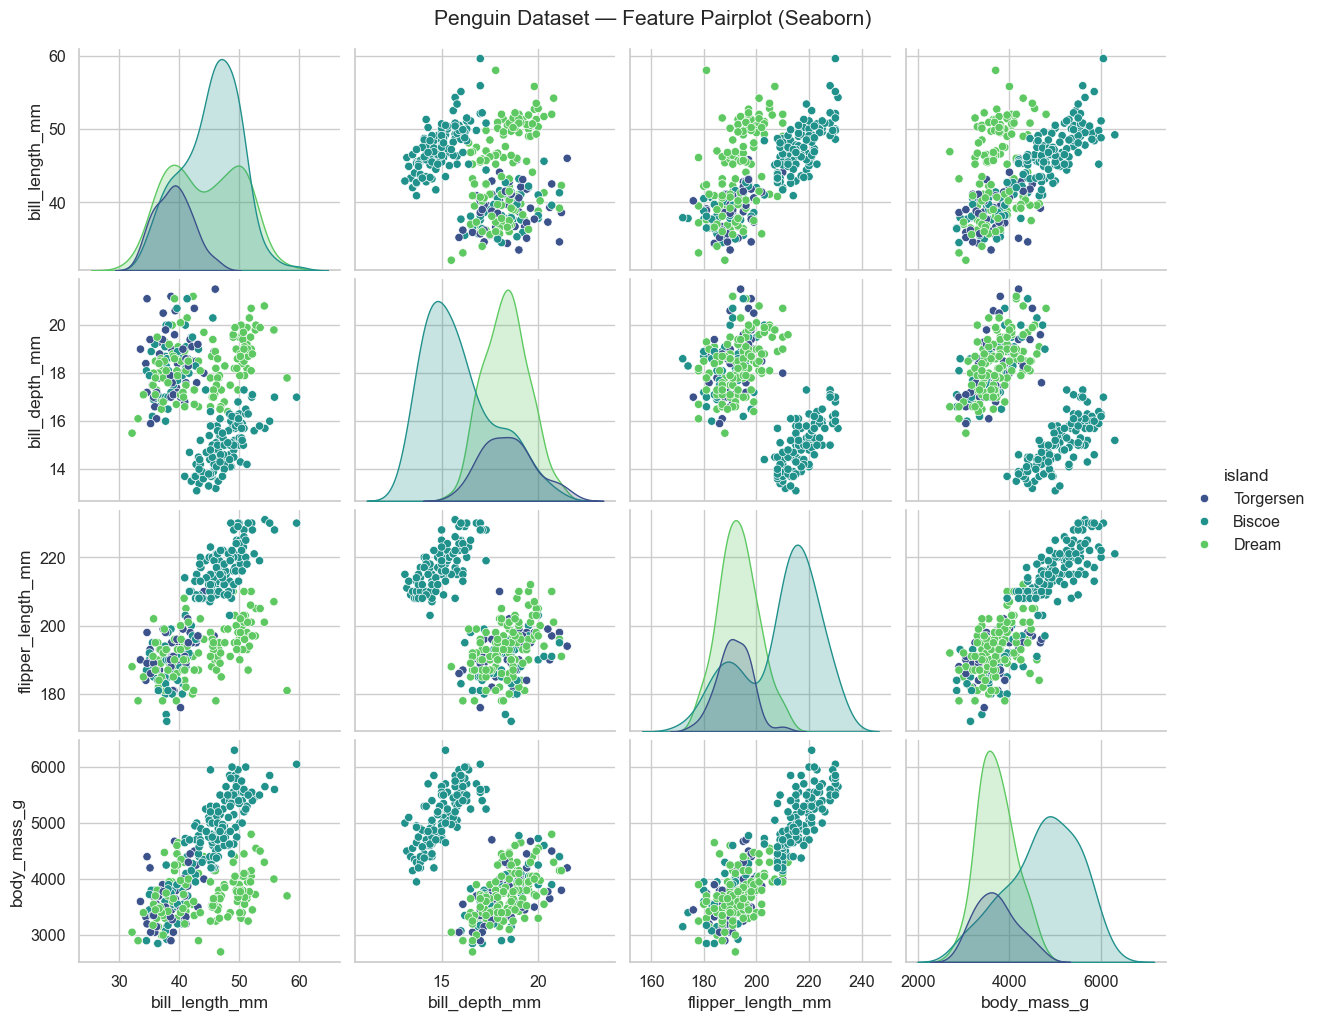

In [50]:
import matplotlib.pyplot as plt
df_cleaned = df.dropna()
penguins_df = df_cleaned.drop(columns=['sex'])
# Seaborn Pairplot
fig_seaborn_pairplot = sns.pairplot(penguins_df, hue='island', palette='viridis', height=2.5, aspect=1.2)
fig_seaborn_pairplot.fig.suptitle('Penguin Dataset — Feature Pairplot (Seaborn)', y=1.02) # Adjust title position
plt.show()

In [51]:
#penguins_df = df_cleaned.drop(columns=['sex'])
penguins_df = df_cleaned

### 2.5.2 Violin Plot

The Violin Plot displays the distribution, probability density, and key summary statistics if of the data. The plot combines a box plot with a kernel density estimator, where the width of the "violin" represents the frequency of the data points at specific values.

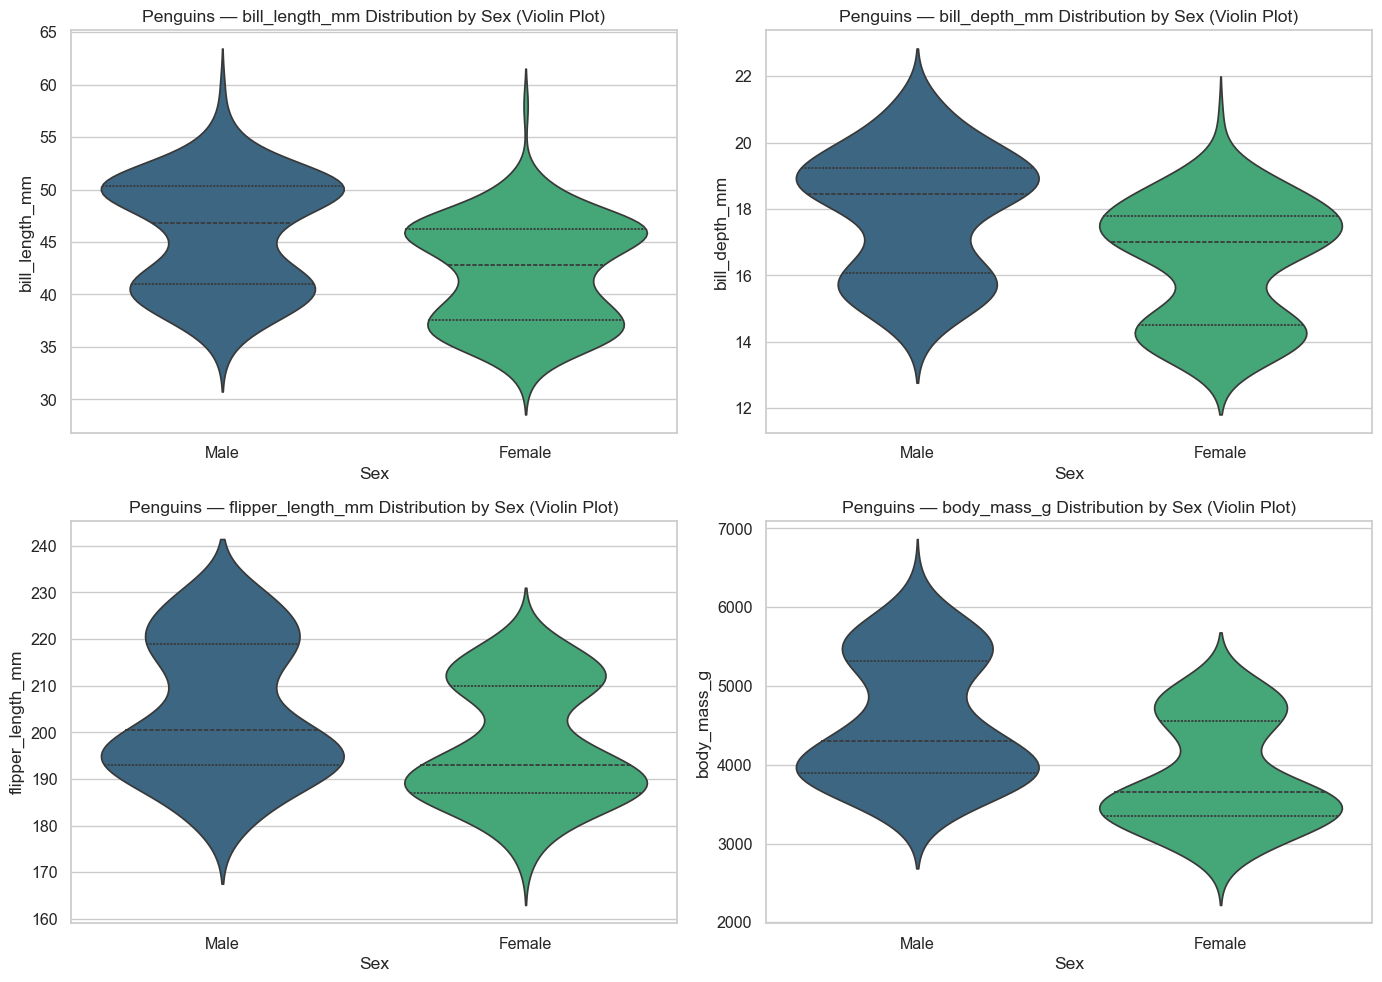

In [52]:
# Numeric columns for violin plots
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Create a figure with subplots for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    sns.violinplot(x='sex', y=feature, data=penguins_df, hue='sex', palette='viridis', ax=axes[i], inner='quartile', legend=False)
    axes[i].set_title(f'Penguins — {feature} Distribution by Sex (Violin Plot)')
    axes[i].set_xlabel('Sex')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### 2.5.3 First few rows of the Cleaned Penguins Dataset

In [53]:
penguins_df.head()

Column,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,Male
1,Adelie,Torgersen,39.5,17.4,186,3800,Female
2,Adelie,Torgersen,40.3,18.0,195,3250,Female
4,Adelie,Torgersen,36.7,19.3,193,3450,Female
5,Adelie,Torgersen,39.3,20.6,190,3650,Male


### 2.5.4 Feature Correlation Matrix

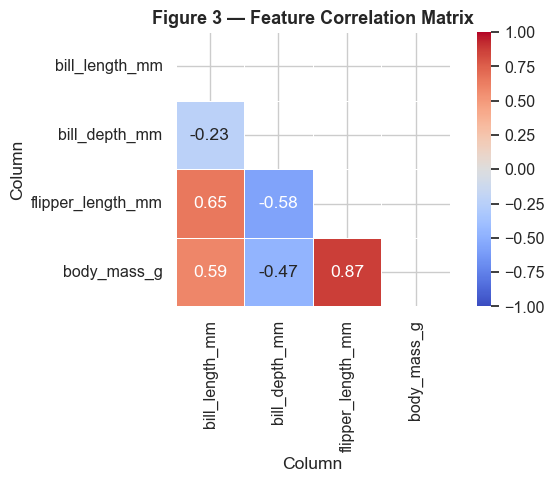

In [54]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = penguins_df.iloc[:, 2:6].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
    xticklabels=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    yticklabels=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    ax=ax
)
ax.set_title('Figure 3 — Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# print(corr.to_string())
# print()
# corr_table = corr.to_string
# print("")
# print("===Feature Correlation Matrix ===")
#
# corr

### 2.7 Classification Models

doucument spliting the data and put code here

In [55]:
# ── Preprocessing & pipeline ───────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV
)
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Classifiers ────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier, export_text
from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import SVC

In [56]:
# penguins_df.head()

#### 2.7.1 Feature Encoding

Features "island" and "species" are encoded using LabelEncoder to convert categorical variables into numerical format for machine learning models. This step is necessary because most machine learning algorithms require numerical input data. The first few rows of the transformed dataset are shown below.


In [57]:
# Encode categorical features - island and species
le = LabelEncoder()
penguins_df['species_enc'] =  le.fit_transform(penguins_df['species'])
penguins_df['island_enc'] =  le.fit_transform(penguins_df['island'])

# Encode target label
penguins_df['sex_enc']= le.fit_transform(penguins_df['sex'])

penguins_df.head()


Column,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_enc,island_enc,sex_enc
0,Adelie,Torgersen,39.1,18.7,181,3750,Male,0,2,1
1,Adelie,Torgersen,39.5,17.4,186,3800,Female,0,2,0
2,Adelie,Torgersen,40.3,18.0,195,3250,Female,0,2,0
4,Adelie,Torgersen,36.7,19.3,193,3450,Female,0,2,0
5,Adelie,Torgersen,39.3,20.6,190,3650,Male,0,2,1


In [58]:
# penguins_df.head()

In [59]:
# Define features and target
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_enc', 'species_enc']
X_penguins = penguins_df[feature_cols].values
y_penguins = penguins_df['sex_enc'].values

RANDOM_STATE = 42

# Train/test split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_penguins, y_penguins, test_size=0.5, random_state=RANDOM_STATE, stratify=y_penguins
)

# Scale
scaler_p = StandardScaler()
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled  = scaler_p.transform(X_test_p)

print(f'Training samples: {X_train_p.shape[0]}')
print(f'Test samples:     {X_test_p.shape[0]}')

Training samples: 166
Test samples:     167


In [60]:
# ── Evaluation ─────────────────────────────────────────────────────────────
# from sklearn.metrics import (
#     classification_report, confusion_matrix,
#     ConfusionMatrixDisplay, accuracy_score
# )

# ── Classifiers ────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
# from sklearn.tree          import DecisionTreeClassifier, export_text
# from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import SVC

#### 2.7.1 Logistic Regression

The Logistic Regression model is a popular choice for classification tasks due to its simplicity and effectiveness. It is particularly useful when dealing with binary or multi-class classification problems. The model learns a linear decision boundary between classes by minimizing the logistic loss function. This makes it suitable for problems where the relationship between features and the target variable is approximately linear. The metric table is shown below, along with the confusion matrix.


In [61]:
# ── Logistic Regression Pipeline ───────────────────────────────────────────
# Input:  X_train (120×4), y_train (120,)
# Output: cv_scores_lr (5 accuracy values), y_pred_lr (30 predictions)
import  pandas as pd

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        solver='lbfgs',
        max_iter=200,
        C=1.0,
        multi_class='multinomial',
        random_state=42
    ))
])

target_names = penguins_df.sex.unique()

# 5-fold stratified CV on training data
# Returns: array of 5 accuracy scores (one per fold)
cv_scores_lr = cross_val_score(lr_pipe, X_train_p_scaled, y_train_p, cv=5,
                               scoring='accuracy')
#print(f'LR  CV Accuracy : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

# Train on full training set; evaluate on held-out test set
lr_pipe.fit(X_train_p_scaled, y_train_p)
y_pred_lr = lr_pipe.predict(X_test_p_scaled)

lr_accuracy = round(accuracy_score(y_test_p, y_pred_lr),4)


In [62]:
report_dict_lr = classification_report(y_test_p, y_pred_lr, target_names=target_names, output_dict=True)
df_report_lr = pd.DataFrame(report_dict_lr).transpose()
df_report_lr

,precision,recall,f1-score,support
Male,0.928571,0.939759,0.934132,83.000000
Female,0.939759,0.928571,0.934132,84.000000
accuracy,0.934132,0.934132,0.934132,0.934132
macro avg,0.934165,0.934165,0.934132,167.000000
weighted avg,0.934199,0.934132,0.934132,167.000000


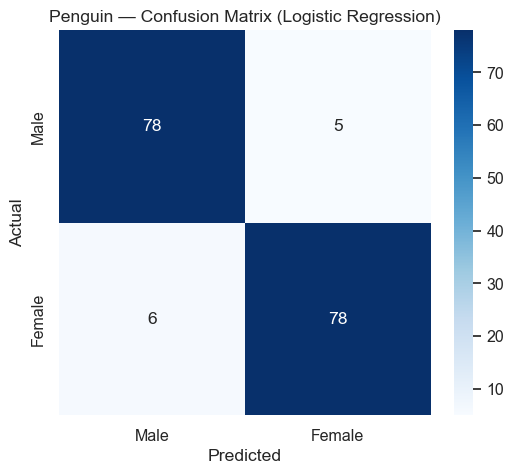

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
cm_penguins_lr = confusion_matrix(y_test_p, y_pred_lr)
# Seaborn confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_penguins_lr, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Penguin — Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 2.7.2  Support Vector Machine

The Support Vector Machine (SVM) is a powerful classification algorithm that aims to find the optimal hyperplane that maximally separates different classes in the feature space. It is particularly effective in high-dimensional spaces and can handle both linear and non-linear classification tasks through the use of kernel functions. The SVM model is trained using a training dataset and then used to make predictions on unseen data. The metric table is shown below, along with the confusion matrix.

In [64]:
# ── SVM Pipeline ───────────────────────────────────────────────────────────
# Input:  X_train (120×4), y_train (120,)
# Output: cv_scores_svm (5 accuracy values), y_pred_svm (30 predictions)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,   # enables predict_proba() via Platt scaling
        random_state=42
    ))
])

cv_scores_svm = cross_val_score(svm_pipe, X_train_p_scaled, y_train_p,
                                cv=5, scoring='accuracy')
#print(f'SVM CV Accuracy : {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}')

svm_pipe.fit(X_train_p_scaled, y_train_p)
y_pred_svm = svm_pipe.predict(X_test_p_scaled)

# print(f'SVM Test Accuracy: {accuracy_score(y_test_p, y_pred_svm):.4f}')
# print()
# print(classification_report(y_test_p, y_pred_svm, target_names=target_names))

In [65]:
report_dict_svm = classification_report(y_test_p, y_pred_svm, target_names=target_names, output_dict=True)
df_report_svm = pd.DataFrame(report_dict_svm).transpose()
df_report_svm

,precision,recall,f1-score,support
Male,0.927711,0.927711,0.927711,83.000000
Female,0.928571,0.928571,0.928571,84.000000
accuracy,0.928144,0.928144,0.928144,0.928144
macro avg,0.928141,0.928141,0.928141,167.000000
weighted avg,0.928144,0.928144,0.928144,167.000000


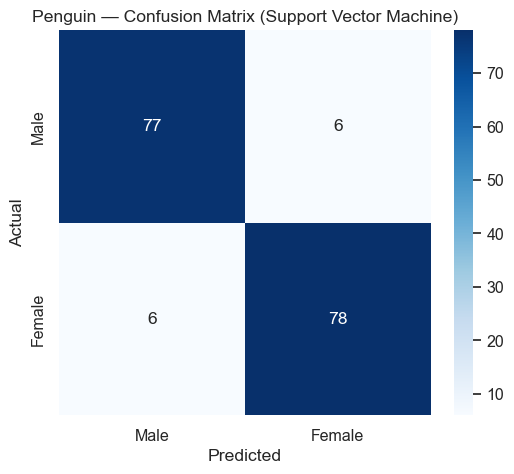

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
cm_penguins_svm = confusion_matrix(y_test_p, y_pred_svm)
# Seaborn confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_penguins_svm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Penguin — Confusion Matrix (Support Vector Machine)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 2.7.3 KNN

The model K-Nearest Neighbors (KNN) is a simple yet effective classification algorithm that classifies data points based on their proximity to neighboring data points. It is particularly useful when dealing with small to medium-sized datasets and when the decision boundary is not linear. The KNN model is trained using a training dataset and then used to make predictions on unseen data. The metric table is shown below, along with the confusion matrix.

In [67]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn = knn.fit(X_train_p_scaled, y_train_p)
y_pred_knn = knn.predict(X_test_p_scaled)

# Preciision, recall, f-score from the multi-class support function
# print(classification_report(y_test_p, y_pred_knn))
print('Accuracy score: ', round(accuracy_score(y_test_p, y_pred_knn), 2))
# print('F1 Score: ', round(f1_score(y_test_p, y_pred_knn), 2))


Accuracy score:  0.92


In [68]:
report_dict_knn = classification_report(y_test_p, y_pred_knn, target_names=target_names, output_dict=True)
df_report_knn = pd.DataFrame(report_dict_knn).transpose()
df_report_knn

,precision,recall,f1-score,support
Male,0.905882,0.927711,0.916667,83.000000
Female,0.926829,0.904762,0.915663,84.000000
accuracy,0.916168,0.916168,0.916168,0.916168
macro avg,0.916356,0.916236,0.916165,167.000000
weighted avg,0.916419,0.916168,0.916162,167.000000


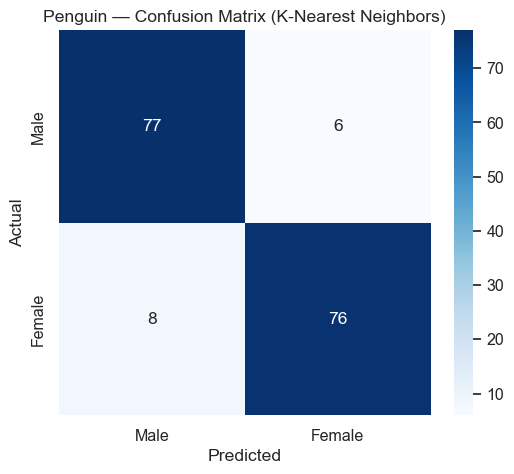

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
cm_penguins_knn = confusion_matrix(y_test_p, y_pred_knn)
# Seaborn confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_penguins_knn, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Penguin — Confusion Matrix (K-Nearest Neighbors)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 3.0 Model Selection and Justification

### 3.1 Comparative Model Performance

The table below summarizes the performance metrics of the K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and Logistic Regression models for the Palmer Penguins dataset. The metrics include precision, recall, F1-score, and accuracy, with higher values indicating better performance. The metics are also visualized in the chart below the table.

All models performed similarly, with KNN and SVM showing slightly higher precision and recall compared to Logistic Regression. However, Logistic Regression had the highest F1-score and accuracy, making it the best-performing model for this classification task.

In [70]:
knn_acc = df_report_knn.loc['accuracy', 'f1-score']
svm_acc = df_report_svm.loc['accuracy', 'f1-score']
lr_acc = df_report_lr.loc['accuracy', 'f1-score']

report_summary_knn = df_report_knn.loc['weighted avg'].copy()
report_summary_knn['accuracy'] = knn_acc
report_summary_knn.name = 'KNN'

report_summary_svm = df_report_svm.loc['weighted avg'].copy()
report_summary_svm['accuracy'] = svm_acc
report_summary_svm.name = 'SVM'

report_summary_lr = df_report_lr.loc['weighted avg'].copy()
report_summary_lr['accuracy'] = lr_acc
report_summary_lr.name = 'LR'

model_summary_df = pd.DataFrame([
    report_summary_knn,
    report_summary_svm,
    report_summary_lr
])

model_summary_df

,precision,recall,f1-score,support,accuracy
KNN,0.916419,0.916168,0.916162,167.0,0.916168
SVM,0.928144,0.928144,0.928144,167.0,0.928144
LR,0.934199,0.934132,0.934132,167.0,0.934132


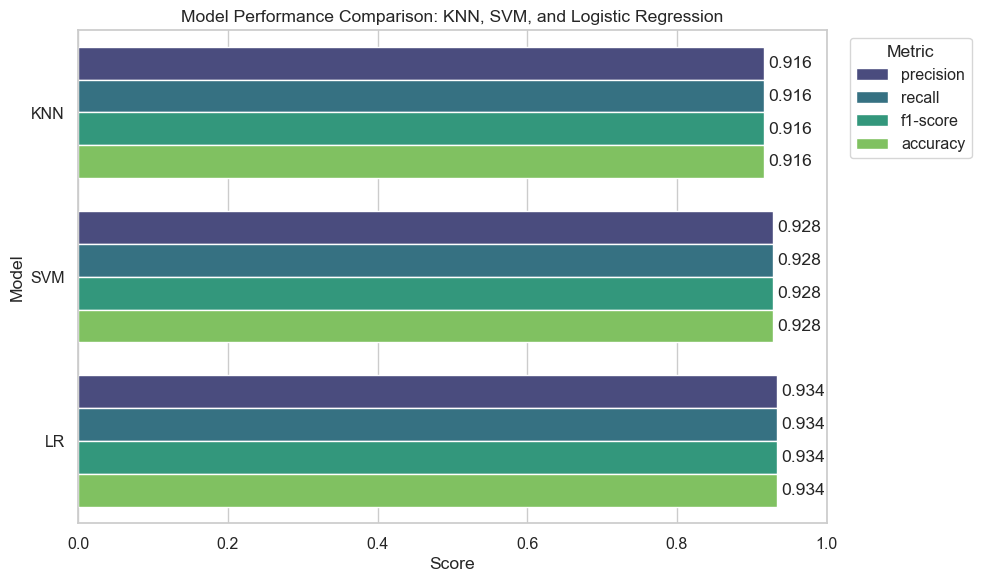

In [71]:
model_metrics_df = model_summary_df[['precision', 'recall', 'f1-score', 'accuracy']].copy()
model_metrics_long = (
    model_metrics_df
    .reset_index(names='Model')
    .melt(id_vars='Model', var_name='Metric', value_name='Score')
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=model_metrics_long,
    y='Model',
    x='Score',
    hue='Metric',
    palette='viridis'
)

ax.set_title('Model Performance Comparison: KNN, SVM, and Logistic Regression')
ax.set_xlabel('Score')
ax.set_ylabel('Model')
ax.set_xlim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Key Findings and Insights

The model performance was similar and suggests that  all three models should be considered for further analysis and testing.

## 5. Limitations and Future Work

The dataset is small and thus, may cause overfitting, and the models may not generalize well to new data. The classes were well-balanced, and data quality was high, with few missing values for the initial dataset. The models would benefit from further tuning and validation on a larger dataset. Advanced classification techniques and models should also be considered for future work.